Only run code cells one time.\
First cell: Reshapes ground_truth to 128x128, due to satlas recreating it to 128x128\
Second cell: Create YAML file

In [ ]:
# (optioneel maar sterk aangeraden)
python -m venv satlas_env
satlas_env\Scripts\activate

pip install numpy==1.26.4
pip install torch==2.0.1 torchvision==0.15.2 --index-url https://download.pytorch.org/whl/cu121
pip install basicsr opencv-python scikit-image pyyaml
pip install "urllib3<2"
pip install ipykernel jupyter

python -m ipykernel install --user --name satlas --display-name "Python (satlas)"

In [ ]:
# import os
# import cv2

# gt_folder = "ground_truth"
# gt_resized_folder = "gt_resized"

# os.makedirs(gt_resized_folder, exist_ok=True)

# for f in os.listdir(gt_folder):
#     if f.lower().endswith(('.png','.jpg','.jpeg')):
#         img = cv2.imread(os.path.join(gt_folder, f))

#         if img is None:
#             print(f"Skip {f}")
#             continue


#         img_resized = cv2.resize(img, (128, 128))

#         cv2.imwrite(os.path.join(gt_resized_folder, f), img_resized)

# print("✅ gt_resized gevuld!")

✅ gt_resized gevuld!


In [ ]:
# import os

# base_dir = os.getcwd()  # huidige project map

# yaml_content = f"""
# name: infer_1S2
# model_type: SSRESRGANModel
# scale: 4
# num_gpu: 0   # ⚠️ force CPU (belangrijk!)

# data_dir: {os.path.join(base_dir, "inputs")}
# save_path: {os.path.join(base_dir, "results_satlas")}

# n_lr_images: 1

# network_g:
#   type: SSR_RRDBNet
#   num_in_ch: 3
#   num_out_ch: 3
#   num_feat: 64
#   num_block: 23
#   num_grow_ch: 32

# path:
#   pretrain_network_g: {os.path.join(base_dir, "ssr", "esrgan_1S2.pth")}
#   param_key_g: params_ema
#   strict_load_g: true
# """

# # YAML opslaan
# yaml_path = os.path.join(base_dir, "infer_1S2.yml")

# with open(yaml_path, "w") as f:
#     f.write(yaml_content)

# print("YAML file aangemaakt op:", yaml_path)

YAML file aangemaakt op: c:\Users\ryanh\Documents\GitHub\satlas-super-resolution\infer_1S2.yml


In [31]:
import os

# ===== FIX OpenMP crash =====
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

# ===== FIX basicsr torchvision bug =====
import site

for path in site.getsitepackages():
    target_file = os.path.join(path, "basicsr", "data", "degradations.py")
    
    if os.path.exists(target_file):
        print("🔧 Patching basicsr:", target_file)
        
        with open(target_file, "r") as f:
            content = f.read()

        content = content.replace(
            "from torchvision.transforms.functional_tensor import rgb_to_grayscale",
            "from torchvision.transforms.functional import rgb_to_grayscale"
        )

        with open(target_file, "w") as f:
            f.write(content)

        print("✅ basicsr patched!")

🔧 Patching basicsr: c:\Users\ryanh\anaconda3\Lib\site-packages\basicsr\data\degradations.py
✅ basicsr patched!


In [4]:
!python ssr/my_infer.py -opt infer_1S2.yml

⚠️ GPU niet beschikbaar, fallback naar CPU
🔧 Model bouwen...
📦 Laden van weights: C:/Users/ryanh/Documents/GitHub/satlas-super-resolution/ssr/esrgan_1S2.pth
✅ Model klaar!
SSR_RRDBNet(
  (conv_first): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (body): Sequential(
    (0): RRDB(
      (rdb1): ResidualDenseBlock(
        (conv1): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (conv2): Conv2d(96, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (conv3): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (conv4): Conv2d(160, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (conv5): Conv2d(192, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (lrelu): LeakyReLU(negative_slope=0.2, inplace=True)
      )
      (rdb2): ResidualDenseBlock(
        (conv1): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (conv2): Conv2d(96, 32, kernel_size=(3, 3), stride=

c:\Users\ryanh\Documents\GitHub\satlas-super-resolution\.venv\Lib\site-packages\torchvision\transforms\functional_tensor.py:5: UserWarning: The torchvision.transforms.functional_tensor module is deprecated in 0.15 and will be **removed in 0.17**. Please don't rely on it. You probably just need to use APIs in torchvision.transforms.functional or in torchvision.transforms.v2.functional.
  warnings.warn(


Using folder: results_satlas\tile_r0000_c0000


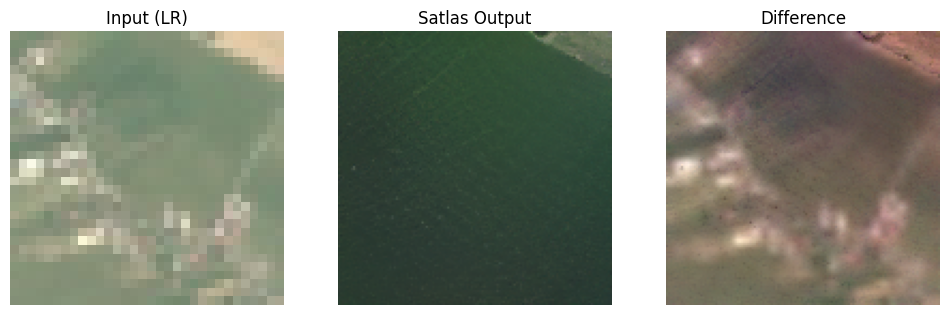

In [6]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os

base_path = "results_satlas"

folders = os.listdir(base_path)

if len(folders) == 0:
    raise ValueError("Geen resultaten gevonden!")

folder = os.path.join(base_path, folders[0])
print("Using folder:", folder)

lr_path = os.path.join(folder, "lr.png")
sr_path = os.path.join(folder, "sr.png")

if not os.path.exists(lr_path) or not os.path.exists(sr_path):
    raise ValueError("lr.png of sr.png ontbreekt!")

lr = cv2.imread(lr_path)
sr = cv2.imread(sr_path)

if lr is None or sr is None:
    raise ValueError("Images konden niet geladen worden!")

# convert naar RGB
lr = cv2.cvtColor(lr, cv2.COLOR_BGR2RGB)
sr = cv2.cvtColor(sr, cv2.COLOR_BGR2RGB)

# resize LR naar SR size
lr_resized = cv2.resize(lr, (sr.shape[1], sr.shape[0]))

# verschil
diff = np.abs(sr.astype(np.float32) - lr_resized.astype(np.float32))
diff = diff / (diff.max() + 1e-8)

# plot
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(lr)
plt.title("Input (LR)")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(sr)
plt.title("Satlas Output")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(diff)
plt.title("Difference")
plt.axis("off")

plt.show()

(32, 32, 3) uint8 104 251


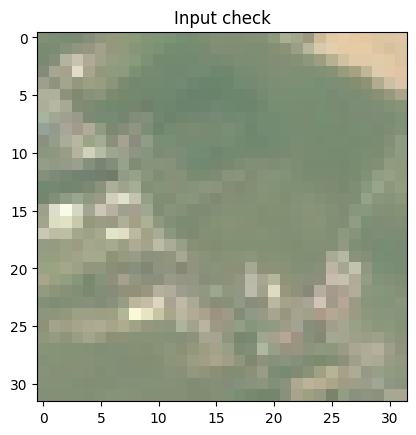

In [10]:
im = cv2.imread(lr_path)
print(im.shape, im.dtype, im.min(), im.max())

import matplotlib.pyplot as plt
plt.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
plt.title("Input check")
plt.show()